In [ ]:
# ========= Integrantes =========
#Grupo 8
#NOMBRE: DIEGO JAVIER MORALES MONZÓN			CARNÉ: 1132119
#NOMBRE: ESTUARDO JOSÉ VILLEDA NAVARRO			CARNÉ: 1003519
#NOMBRE: JORGE WALDEMAR GARCÍA BALDIZÓN			CARNÉ: 1220019
#NOMBRE: JOSÉ DANIEL DE LEÓN CHANG				CARNÉ: 1170419

In [41]:
%matplotlib inline

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
clientes = pd.read_csv("clientes.txt", sep="|", header=0)
transacciones = pd.read_csv("transacciones.txt", sep="|", header=0)

In [43]:
clientes.head()

,nombre,apellido,tarjeta,fecha_nacimiento
0,Rosa,Barrientos,1,1984-12-19
1,Juan,Media,2,1954-01-08
2,José,Coronado,3,1984-08-25
3,Mario,Flores,4,1982-11-11
4,Margarita,Muñoz,5,1984-04-11


In [44]:
clientes.dtypes

nombre                str
apellido              str
tarjeta             int64
fecha_nacimiento      str
dtype: object

In [45]:
transacciones.dtypes

tarjeta     float64
monto       float64
comercio        str
fecha           str
tipo            str
dtype: object

In [46]:
clientes['fecha_nacimiento'] = clientes['fecha_nacimiento'].astype('datetime64[ns]')

In [47]:
transacciones['fecha'] = transacciones['fecha'].astype('datetime64[ns]')

In [48]:
clientes.dtypes

nombre                         str
apellido                       str
tarjeta                      int64
fecha_nacimiento    datetime64[ns]
dtype: object

In [49]:
transacciones.dtypes

tarjeta            float64
monto              float64
comercio               str
fecha       datetime64[ns]
tipo                   str
dtype: object

In [50]:
tarjetas_unicas = clientes['tarjeta'].unique()
len(tarjetas_unicas)

110

In [51]:
tarjetas_transacciones_unicas = transacciones['tarjeta'].unique()
len(tarjetas_transacciones_unicas)

101

In [52]:
qty_transacciones = transacciones['tarjeta'].value_counts(ascending=False, dropna=False)
qty_transacciones

tarjeta
NaN      137
96.0      66
100.0     65
57.0      62
74.0      62
        ... 
67.0      39
56.0      39
6.0       39
5.0       37
34.0      34
Name: count, Length: 101, dtype: int64

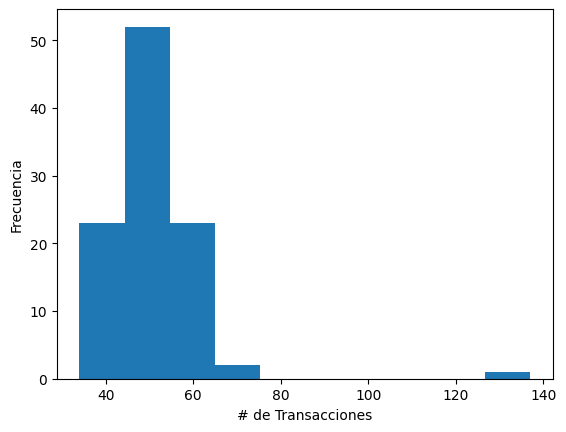

In [53]:
plt.xlabel('# de Transacciones')
plt.ylabel('Frecuencia')
_ = plt.hist(qty_transacciones, bins=10)

In [54]:
transacciones_filt = transacciones[transacciones['tarjeta'].notnull()]

In [55]:
qty_transacciones_filt = transacciones_filt['tarjeta'].value_counts(ascending=False, dropna=False)
qty_transacciones_filt

tarjeta
96.0     66
100.0    65
57.0     62
74.0     62
11.0     61
         ..
67.0     39
56.0     39
6.0      39
5.0      37
34.0     34
Name: count, Length: 100, dtype: int64

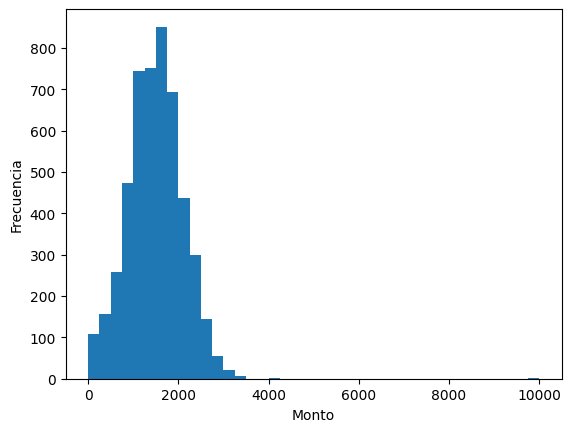

In [56]:
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
_ = plt.hist(transacciones_filt['monto'], bins=40)

In [57]:
transacciones_filt[transacciones_filt['monto'] > 4000]

,tarjeta,monto,comercio,fecha,tipo
2281,57.0,4094.69,Gasolineras,2020-02-07,transaccion
4118,37.0,10000.00,Supermercados,2020-05-04,reconciliacion


In [58]:
transacciones_filt = transacciones_filt[transacciones_filt['monto'] < 7000]

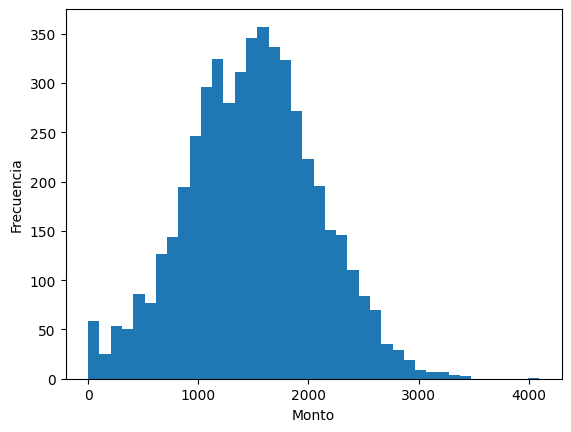

In [59]:
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
_ = plt.hist(transacciones_filt['monto'], bins=40)

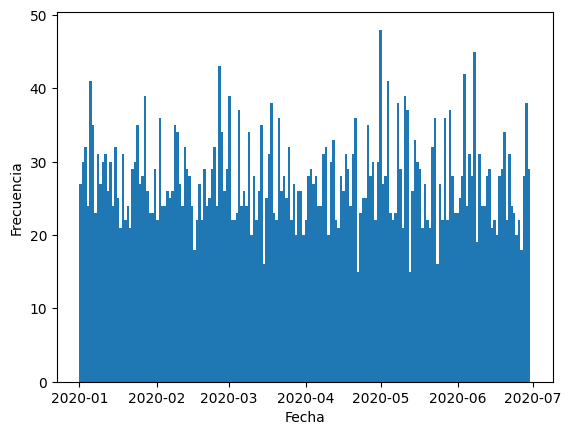

In [60]:
plt.xlabel('Fecha')
plt.ylabel('Frecuencia')
_ = plt.hist(transacciones_filt['fecha'], bins=182)

In [61]:
transacciones_filt['diaSemana'] = transacciones_filt['fecha'].dt.day_name()

In [62]:
transacciones_filt['weekday'] = transacciones_filt['fecha'].dt.dayofweek

In [63]:
transacciones_filt['diaMes'] = transacciones_filt['fecha'].dt.day

In [64]:
transacciones_filt['mes'] = transacciones_filt['fecha'].dt.month

In [65]:
transacciones_filt.head()

,tarjeta,monto,comercio,fecha,tipo,diaSemana,weekday,diaMes,mes
0,90.0,2067.31,Gasolineras,2020-01-05,transaccion,Sunday,6,5,1
1,67.0,1871.79,Supermercados,2020-02-16,transaccion,Sunday,6,16,2
2,1.0,2171.59,Supermercados,2020-06-04,transaccion,Thursday,3,4,6
3,90.0,692.46,Gasolineras,2020-01-14,transaccion,Tuesday,1,14,1
4,31.0,1463.87,Tiendas por Departamento,2020-05-28,transaccion,Thursday,3,28,5


In [66]:
qty_dias = transacciones_filt['diaSemana'].value_counts(ascending=False, dropna=False)
qty_dias

diaSemana
Monday       759
Friday       742
Saturday     737
Sunday       709
Thursday     701
Wednesday    701
Tuesday      650
Name: count, dtype: int64

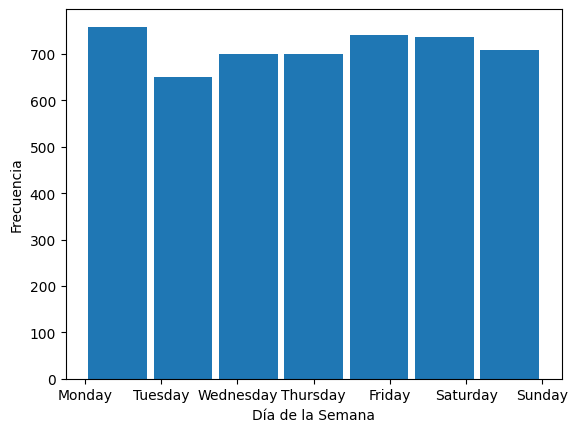

In [67]:
plt.xlabel('Día de la Semana')
plt.ylabel('Frecuencia')
_ = plt.hist(transacciones_filt.sort_values('weekday')['diaSemana'], bins=7, rwidth=0.9)

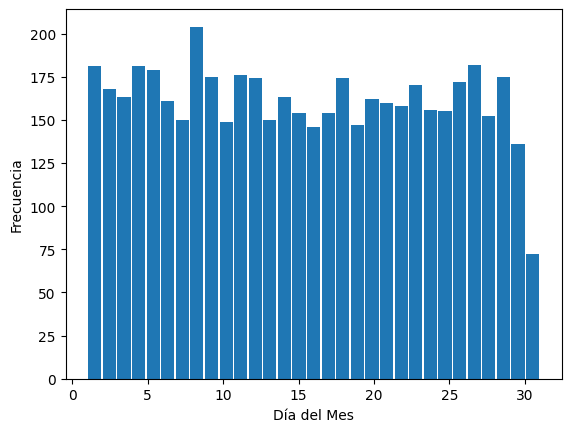

In [68]:
plt.xlabel('Día del Mes')
plt.ylabel('Frecuencia')
_ = plt.hist(transacciones_filt['diaMes'], bins=31, rwidth=0.9)

In [69]:
qty_tipo = transacciones_filt['tipo'].value_counts(ascending=False, dropna=False)
qty_tipo

tipo
transaccion       4961
reconciliacion      38
Name: count, dtype: int64

In [70]:
reconciliacion = transacciones_filt[transacciones_filt['tipo'] == 'reconciliacion']
reconciliacion

,tarjeta,monto,comercio,fecha,tipo,diaSemana,weekday,diaMes,mes
218,44.0,0.0,Supermercados,2020-02-02,reconciliacion,Sunday,6,2,2
309,36.0,0.0,Restaurantes,2020-06-29,reconciliacion,Monday,0,29,6
381,68.0,0.0,Restaurantes,2020-02-29,reconciliacion,Saturday,5,29,2
465,31.0,0.0,Tiendas por Departamento,2020-04-27,reconciliacion,Monday,0,27,4
590,54.0,0.0,Supermercados,2020-05-14,reconciliacion,Thursday,3,14,5
593,37.0,0.0,Comercio General,2020-01-23,reconciliacion,Thursday,3,23,1
615,32.0,0.0,Abarroterias,2020-06-20,reconciliacion,Saturday,5,20,6
1297,62.0,0.0,Farmacias,2020-01-20,reconciliacion,Monday,0,20,1
1500,96.0,0.0,Farmacias,2020-03-04,reconciliacion,Wednesday,2,4,3
1646,93.0,0.0,Supermercados,2020-02-16,reconciliacion,Sunday,6,16,2


In [71]:
reconciliacion[reconciliacion['monto'] > 0]

,tarjeta,monto,comercio,fecha,tipo,diaSemana,weekday,diaMes,mes


In [72]:
transacciones_filt = transacciones_filt[transacciones_filt['tipo'] != 'reconciliacion']
transacciones_filt['tipo'].unique()

<StringArray>
['transaccion']
Length: 1, dtype: str

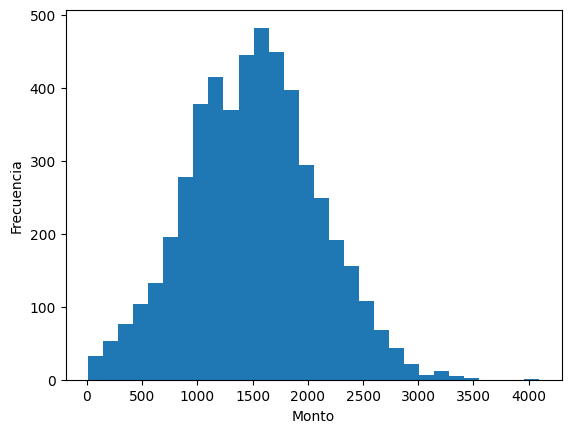

In [73]:
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
_ = plt.hist(transacciones_filt['monto'], bins=30)

{'whiskers': [<matplotlib.lines.Line2D at 0x1db81afc2d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1db81afc550>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db81afc190>],
 'medians': [<matplotlib.lines.Line2D at 0x1db81afc7d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db81afc910>],
 'means': []}

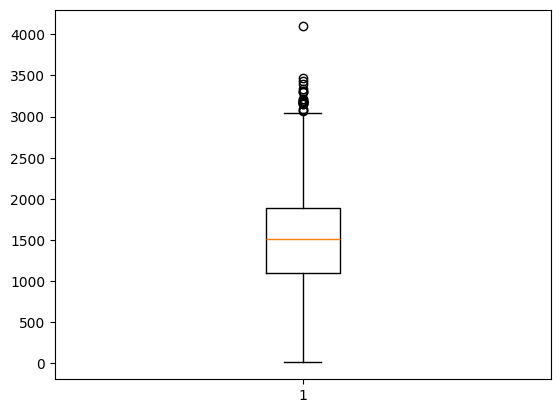

In [74]:
plt.boxplot(transacciones_filt['monto'])

(array([1.610e+02, 4.330e+02, 1.069e+03, 1.295e+03, 1.140e+03, 5.960e+02,
        2.190e+02, 4.000e+01, 7.000e+00, 1.000e+00]),
 array([  10.91 ,  419.288,  827.666, 1236.044, 1644.422, 2052.8  ,
        2461.178, 2869.556, 3277.934, 3686.312, 4094.69 ]),
 <BarContainer object of 10 artists>)

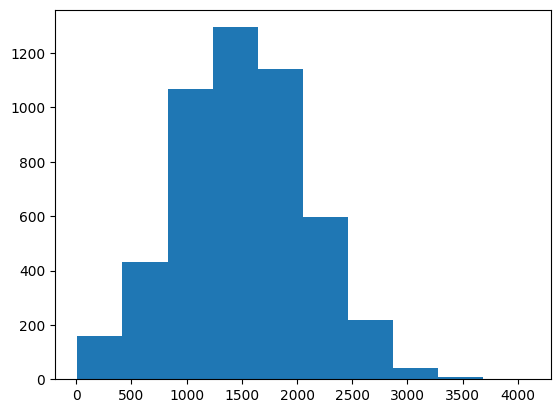

In [75]:
plt.hist(transacciones_filt['monto'])

In [76]:
clientes.head()

,nombre,apellido,tarjeta,fecha_nacimiento
0,Rosa,Barrientos,1,1984-12-19
1,Juan,Media,2,1954-01-08
2,José,Coronado,3,1984-08-25
3,Mario,Flores,4,1982-11-11
4,Margarita,Muñoz,5,1984-04-11


In [78]:
clientes["edad"] = clientes["fecha_nacimiento"].apply(
    lambda x: (pd.Timestamp.now() - x).days / 365
)

clientes["edad"] = clientes["edad"].astype("int64")

In [79]:
clientes.head()

,nombre,apellido,tarjeta,fecha_nacimiento,edad
0,Rosa,Barrientos,1,1984-12-19,41
1,Juan,Media,2,1954-01-08,72
2,José,Coronado,3,1984-08-25,41
3,Mario,Flores,4,1982-11-11,43
4,Margarita,Muñoz,5,1984-04-11,42


(array([ 5., 16.,  5.,  8., 17., 12.,  9., 16.,  7., 15.]),
 array([26., 31., 36., 41., 46., 51., 56., 61., 66., 71., 76.]),
 <BarContainer object of 10 artists>)

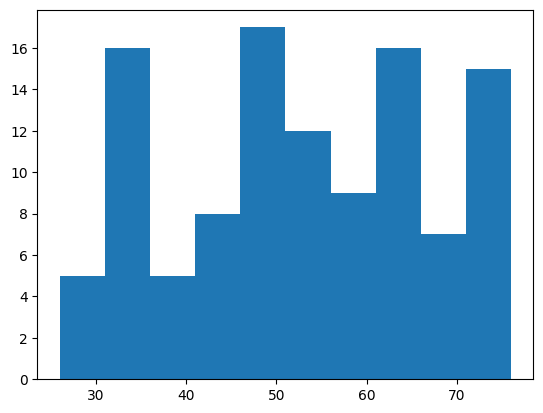

In [80]:
plt.hist(clientes["edad"])

In [81]:
transacciones_filt['fecha'].min()

Timestamp('2020-01-01 00:00:00')

In [82]:
transacciones_filt['fecha'].max()

Timestamp('2020-06-30 00:00:00')

In [83]:
fechas = transacciones_filt['fecha'].unique()
fechas = pd.DataFrame(fechas, columns=['fecha'])

In [84]:
fechas

,fecha
0,2020-01-05
1,2020-02-16
2,2020-06-04
3,2020-01-14
4,2020-05-28
...,...
177,2020-01-13
178,2020-02-20
179,2020-02-21
180,2020-06-26


In [85]:
fechas['year'] = pd.DatetimeIndex(fechas['fecha']).year
fechas['month'] = pd.DatetimeIndex(fechas['fecha']).month

In [86]:
fechas['fechaMA'] = fechas['year'].astype(str) + "/" + "0" + fechas['month'].astype(str) + "/01"

In [87]:
fechas.head()

,fecha,year,month,fechaMA
0,2020-01-05,2020,1,2020/01/01
1,2020-02-16,2020,2,2020/02/01
2,2020-06-04,2020,6,2020/06/01
3,2020-01-14,2020,1,2020/01/01
4,2020-05-28,2020,5,2020/05/01


In [88]:
fechas = fechas['fechaMA'].unique()
fechas

<StringArray>
['2020/01/01', '2020/02/01', '2020/06/01', '2020/05/01', '2020/04/01',
 '2020/03/01']
Length: 6, dtype: str

In [89]:
clientes.shape

(110, 5)

In [90]:
len(clientes['tarjeta'].unique())

110

In [91]:
len(clientes.groupby(['nombre', 'apellido', 'fecha_nacimiento']).count())

110

In [92]:
len(clientes.groupby(['nombre', 'apellido']).count())

100

In [93]:
nombres_gb = pd.DataFrame(
    clientes.groupby(['nombre', 'apellido']).size().reset_index(name='counts')
)

nombres_gb[nombres_gb.counts > 1]

,nombre,apellido,counts
14,Andrés,Rivera,2
15,Andrés,Ruíz,2
43,Gustavo,Ruíz,2
53,José,Coronado,2
56,Juan,Calderón,2
61,Juan,Perez,3
70,Luis,Figueroa,2
71,Luis,Martinez,2
79,Maria,Juarez,2


In [94]:
tarjetas_gb = pd.DataFrame(
    clientes.groupby(['tarjeta']).size().reset_index(name='counts')
)

tarjetas_gb[tarjetas_gb.counts > 1]

,tarjeta,counts


In [95]:
fechas = pd.DataFrame(fechas, columns=['fechaMA'])
fechas.head()

,fechaMA
0,2020/01/01
1,2020/02/01
2,2020/06/01
3,2020/05/01
4,2020/04/01


In [96]:
clientes['tmp'] = 1
fechas['tmp'] = 1

In [97]:
fechas.head()

,fechaMA,tmp
0,2020/01/01,1
1,2020/02/01,1
2,2020/06/01,1
3,2020/05/01,1
4,2020/04/01,1


In [98]:
clientes.shape

(110, 6)

In [99]:
tabla_base = pd.merge(clientes, fechas, on=['tmp'])
tabla_base = tabla_base.drop('tmp', axis=1)
tabla_base.head(6)

,nombre,apellido,tarjeta,fecha_nacimiento,edad,fechaMA
0,Rosa,Barrientos,1,1984-12-19,41,2020/01/01
1,Rosa,Barrientos,1,1984-12-19,41,2020/02/01
2,Rosa,Barrientos,1,1984-12-19,41,2020/06/01
3,Rosa,Barrientos,1,1984-12-19,41,2020/05/01
4,Rosa,Barrientos,1,1984-12-19,41,2020/04/01
5,Rosa,Barrientos,1,1984-12-19,41,2020/03/01


In [100]:
tabla_base.shape

(660, 6)

In [101]:
tabla_base.rename(columns={'fechaMA': 'mes_anio'}, inplace=True)
tabla_base.head()

,nombre,apellido,tarjeta,fecha_nacimiento,edad,mes_anio
0,Rosa,Barrientos,1,1984-12-19,41,2020/01/01
1,Rosa,Barrientos,1,1984-12-19,41,2020/02/01
2,Rosa,Barrientos,1,1984-12-19,41,2020/06/01
3,Rosa,Barrientos,1,1984-12-19,41,2020/05/01
4,Rosa,Barrientos,1,1984-12-19,41,2020/04/01


In [102]:
tabla_base['mes_anio'] = tabla_base['mes_anio'].apply(pd.to_datetime)

In [103]:
tabla_base = tabla_base.assign(
    edad = lambda x: ((x['mes_anio'] - x['fecha_nacimiento']).dt.days / 365)
)

tabla_base.head(6)

,nombre,apellido,tarjeta,fecha_nacimiento,edad,mes_anio
0,Rosa,Barrientos,1,1984-12-19,35.057534,2020-01-01
1,Rosa,Barrientos,1,1984-12-19,35.142466,2020-02-01
2,Rosa,Barrientos,1,1984-12-19,35.473973,2020-06-01
3,Rosa,Barrientos,1,1984-12-19,35.389041,2020-05-01
4,Rosa,Barrientos,1,1984-12-19,35.306849,2020-04-01
5,Rosa,Barrientos,1,1984-12-19,35.221918,2020-03-01


In [104]:
transacciones_filt['year'] = pd.DatetimeIndex(transacciones_filt['fecha']).year

transacciones_filt['mes_anio'] = (
    transacciones_filt['year'].astype(str) + "/" + "0" + transacciones_filt['mes'].astype(str)
)

transacciones_filt['mes_anio'] = transacciones_filt['mes_anio'].apply(pd.to_datetime)

In [105]:
transacciones_filt = transacciones_filt.drop(
    columns=['year', 'diaSemana', 'diaMes', 'mes']
)

transacciones_filt.head()

,tarjeta,monto,comercio,fecha,tipo,weekday,mes_anio
0,90.0,2067.31,Gasolineras,2020-01-05,transaccion,6,2020-01-01
1,67.0,1871.79,Supermercados,2020-02-16,transaccion,6,2020-02-01
2,1.0,2171.59,Supermercados,2020-06-04,transaccion,3,2020-06-01
3,90.0,692.46,Gasolineras,2020-01-14,transaccion,1,2020-01-01
4,31.0,1463.87,Tiendas por Departamento,2020-05-28,transaccion,3,2020-05-01


In [106]:
variables_mensual = (
    transacciones_filt
    .groupby(['tarjeta', 'mes_anio'])
    .agg({'comercio': 'count', 'monto': 'sum'})
    .reset_index()
    .rename(columns={'comercio': 'conteo_mensual', 'monto': 'sumatoria_mensual'})
)

In [107]:
variables_mensual = variables_mensual.assign(
    promedio_monto_mensual = lambda x: x['sumatoria_mensual'] / x['conteo_mensual']
)

variables_mensual.head()

,tarjeta,mes_anio,conteo_mensual,sumatoria_mensual,promedio_monto_mensual
0,1.0,2020-01-01,6,7415.41,1235.901667
1,1.0,2020-02-01,5,9578.51,1915.702000
2,1.0,2020-03-01,9,14300.67,1588.963333
3,1.0,2020-04-01,13,22509.28,1731.483077
4,1.0,2020-05-01,4,6377.68,1594.420000


In [108]:
transacciones_filt.loc[
    (transacciones_filt['tarjeta'] == 1) &
    (transacciones_filt['fecha'] <= "2020-01-31 00:00:00")
].groupby("tarjeta")["monto"].mean()

tarjeta
1.0    1235.901667
Name: monto, dtype: float64

In [109]:
tabla_base['mes_anio'] = tabla_base['mes_anio'].astype('datetime64[ns]')

In [110]:
base_vars = tabla_base.merge(
    variables_mensual,
    on=['mes_anio', 'tarjeta'],
    how='left'
)

base_vars.head()

,nombre,apellido,tarjeta,fecha_nacimiento,edad,mes_anio,conteo_mensual,sumatoria_mensual,promedio_monto_mensual
0,Rosa,Barrientos,1,1984-12-19,35.057534,2020-01-01,6.0,7415.41,1235.901667
1,Rosa,Barrientos,1,1984-12-19,35.142466,2020-02-01,5.0,9578.51,1915.702000
2,Rosa,Barrientos,1,1984-12-19,35.473973,2020-06-01,10.0,16552.09,1655.209000
3,Rosa,Barrientos,1,1984-12-19,35.389041,2020-05-01,4.0,6377.68,1594.420000
4,Rosa,Barrientos,1,1984-12-19,35.306849,2020-04-01,13.0,22509.28,1731.483077


In [111]:
len(base_vars[base_vars['conteo_mensual'].isnull()])

60

In [112]:
base_vars[['conteo_mensual', 'sumatoria_mensual', 'promedio_monto_mensual']] = (
    base_vars[['conteo_mensual', 'sumatoria_mensual', 'promedio_monto_mensual']].fillna(value=0)
)

In [113]:
variables_comercio = (
    transacciones_filt
    .groupby(['tarjeta', 'mes_anio', 'comercio'], dropna=False)
    .agg({'tipo': 'count'})
    .reset_index()
    .rename(columns={'tipo': 'conteo_comercio'})
)

In [114]:
conteo_tarjeta = (
    transacciones_filt
    .groupby(['tarjeta', 'mes_anio'], dropna=False)
    .agg({'tipo': 'count'})
    .reset_index()
    .rename(columns={'tipo': 'conteo_mensual'})
)

conteo_tarjeta.head()

,tarjeta,mes_anio,conteo_mensual
0,1.0,2020-01-01,6
1,1.0,2020-02-01,5
2,1.0,2020-03-01,9
3,1.0,2020-04-01,13
4,1.0,2020-05-01,4


In [115]:
variables_comercio = variables_comercio.merge(
    conteo_tarjeta,
    on=['tarjeta', 'mes_anio'],
    how='left'
)

variables_comercio.head()

,tarjeta,mes_anio,comercio,conteo_comercio,conteo_mensual
0,1.0,2020-01-01,Farmacias,1,6
1,1.0,2020-01-01,Restaurantes,1,6
2,1.0,2020-01-01,Ropa,1,6
3,1.0,2020-01-01,Supermercados,3,6
4,1.0,2020-02-01,Gasolineras,1,5


In [116]:
variables_comercio = variables_comercio.assign(
    trans_por = lambda x: x['conteo_comercio'] / x['conteo_mensual']
)

variables_comercio.head()

,tarjeta,mes_anio,comercio,conteo_comercio,conteo_mensual,trans_por
0,1.0,2020-01-01,Farmacias,1,6,0.166667
1,1.0,2020-01-01,Restaurantes,1,6,0.166667
2,1.0,2020-01-01,Ropa,1,6,0.166667
3,1.0,2020-01-01,Supermercados,3,6,0.500000
4,1.0,2020-02-01,Gasolineras,1,5,0.200000


In [117]:
variables_comercio['trans_por'].sum()

np.float64(600.0)

In [118]:
len(variables_comercio.groupby(['tarjeta', 'mes_anio']))

600

In [119]:
variables_comercio[variables_comercio['comercio'].isnull()]

,tarjeta,mes_anio,comercio,conteo_comercio,conteo_mensual,trans_por
1280,46.0,2020-02-01,NaN,1,8,0.125000
1548,56.0,2020-04-01,NaN,1,7,0.142857
1602,58.0,2020-02-01,NaN,1,6,0.166667
2775,100.0,2020-01-01,NaN,1,11,0.090909


In [120]:
variables_comercio_2 = variables_comercio.pivot_table(
    index=['tarjeta', 'mes_anio'],
    columns='comercio',
    values='trans_por',
    dropna=False
).reset_index()

variables_comercio_2 = variables_comercio_2.fillna(0)

variables_comercio_2.head()

comercio,tarjeta,mes_anio,Abarroterias,Comercio General,Electronicos,Farmacias,Gasolineras,Restaurantes,Ropa,Supermercados,Tiendas por Departamento,NaN
0,1.0,2020-01-01,0.000000,0.00,0.000000,0.166667,0.000000,0.166667,0.166667,0.500000,0.000000,0.0
1,1.0,2020-02-01,0.000000,0.00,0.000000,0.000000,0.200000,0.200000,0.000000,0.600000,0.000000,0.0
2,1.0,2020-03-01,0.111111,0.00,0.000000,0.000000,0.111111,0.444444,0.000000,0.222222,0.111111,0.0
3,1.0,2020-04-01,0.076923,0.00,0.076923,0.153846,0.307692,0.230769,0.000000,0.153846,0.000000,0.0
4,1.0,2020-05-01,0.000000,0.25,0.250000,0.000000,0.250000,0.000000,0.250000,0.000000,0.000000,0.0


In [121]:
base_vars = base_vars.merge(
    variables_comercio_2,
    on=['tarjeta', 'mes_anio'],
    how='left'
)

base_vars.head()

,nombre,apellido,tarjeta,fecha_nacimiento,edad,mes_anio,conteo_mensual,sumatoria_mensual,promedio_monto_mensual,Abarroterias,Comercio General,Electronicos,Farmacias,Gasolineras,Restaurantes,Ropa,Supermercados,Tiendas por Departamento,NaN
0,Rosa,Barrientos,1,1984-12-19,35.057534,2020-01-01,6.0,7415.41,1235.901667,0.000000,0.00,0.000000,0.166667,0.000000,0.166667,0.166667,0.500000,0.0,0.0
1,Rosa,Barrientos,1,1984-12-19,35.142466,2020-02-01,5.0,9578.51,1915.702000,0.000000,0.00,0.000000,0.000000,0.200000,0.200000,0.000000,0.600000,0.0,0.0
2,Rosa,Barrientos,1,1984-12-19,35.473973,2020-06-01,10.0,16552.09,1655.209000,0.000000,0.40,0.000000,0.000000,0.000000,0.100000,0.100000,0.400000,0.0,0.0
3,Rosa,Barrientos,1,1984-12-19,35.389041,2020-05-01,4.0,6377.68,1594.420000,0.000000,0.25,0.250000,0.000000,0.250000,0.000000,0.250000,0.000000,0.0,0.0
4,Rosa,Barrientos,1,1984-12-19,35.306849,2020-04-01,13.0,22509.28,1731.483077,0.076923,0.00,0.076923,0.153846,0.307692,0.230769,0.000000,0.153846,0.0,0.0


In [122]:
len(base_vars[base_vars['Farmacias'].isnull()])

60

In [123]:
base_vars = base_vars.fillna(value=0)

In [124]:
len(base_vars[base_vars['Farmacias'].isnull()])

0